# USGS Earthquake Agent Streaming Demo

This notebook demonstrates the dedicated `usgs_earthquake_agent` using GAS streaming mode. It walks through every public skill advertised by the agent:

- Retrieve and export earthquake events
- Map earthquake activity
- Summarize earthquake activity
- Analyze earthquake patterns
- Generate alert-ready summaries
- Generate earthquake reports

The agent does not require a USGS API key. If you provide an OpenAI or GIBD key, the service may use LLM-assisted planning for vague requests; otherwise it uses deterministic request parsing and deterministic USGS/geospatial tools.

## Install and Import

In [ ]:
%pip install -q gas-client requests pandas geopandas matplotlib python-dotenv

In [2]:
from pathlib import Path
from urllib.parse import urljoin, urlparse
import base64
import json
import os

import requests
from dotenv import load_dotenv
from IPython.display import HTML, Image, Markdown, display

from gas_client import GasClient

## User Settings

Use your local server during development or switch `server_url` to the deployed GAS server. Model credentials are optional for this agent.

In [3]:
project_root = Path.cwd()
if project_root.name == "examples_for_using_gas_services":
    project_root = project_root.parent

load_dotenv(project_root / ".env")

server_url = "http://127.0.0.1:4042"
# server_url = "https://www.geospatial-agentic-services.online"

openai_api_key = os.getenv("OPENAI_API_KEY", "").strip()
gibd_api_key = os.getenv("GIBD_API_KEY", "").strip()

credentials = {}
if openai_api_key:
    credentials["OPENAI_API_KEY"] = openai_api_key
elif gibd_api_key:
    credentials["GIBD_API_KEY"] = gibd_api_key

task_credentials = credentials or None
timeout_seconds = 1800

client = GasClient(server_url, artifact_delivery="URL")
earthquake_agent = client.agent("usgs_earthquake_agent")

## Helpers

`run_streaming_task(...)` prints progress events and returns the final task result. `display_task_artifacts(...)` downloads returned artifacts and renders common formats inline.

In [5]:
artifact_cache_dir = project_root / "examples_for_using_gas_services" / "downloaded_gas_artifacts" / "usgs_earthquake_agent"
artifact_cache_dir.mkdir(parents=True, exist_ok=True)


def absolute_url(url):
    if not url:
        return None
    if url.startswith("/"):
        return urljoin(server_url.rstrip("/") + "/", url)
    return url


def artifact_display_name(artifact):
    return artifact.get("filename") or artifact.get("name") or Path(urlparse(artifact.get("url", "")).path).name or "gas_artifact"


def artifact_suffix(artifact):
    name = artifact_display_name(artifact)
    url = artifact.get("url") or ""
    return Path(name).suffix.lower() or Path(urlparse(url).path).suffix.lower()


def download_or_decode_artifact(artifact):
    name = artifact_display_name(artifact)
    suffix = artifact_suffix(artifact)
    if not Path(name).suffix and suffix:
        name = f"{name}{suffix}"
    path = artifact_cache_dir / Path(name).name

    if artifact.get("data"):
        path.write_bytes(base64.b64decode(artifact["data"]))
        return path

    url = absolute_url(artifact.get("url"))
    if not url:
        raise ValueError("Artifact has neither URL nor encoded data.")
    if not path.exists():
        response = requests.get(url, timeout=300)
        response.raise_for_status()
        path.write_bytes(response.content)
    return path


def display_task_artifacts(task_result, *, max_rows=8, only_suffixes=None):
    artifacts = task_result.get("outputs", {}).get("artifacts", [])
    if not artifacts:
        print("No artifacts returned.")
        return []

    displayed_paths = []
    for artifact in artifacts:
        name = artifact_display_name(artifact)
        suffix = artifact_suffix(artifact)
        if only_suffixes and suffix not in only_suffixes:
            continue

        print(f"Artifact: {name}")
        try:
            path = download_or_decode_artifact(artifact)
            displayed_paths.append(path)

            if suffix in {".geojson", ".gpkg", ".shp"}:
                import geopandas as gpd

                gdf = gpd.read_file(path)
                display(gdf.head(max_rows))
            elif suffix == ".csv":
                import pandas as pd

                display(pd.read_csv(path).head(max_rows))
            elif suffix == ".parquet":
                import pandas as pd

                display(pd.read_parquet(path).head(max_rows))
            elif suffix in {".png", ".jpg", ".jpeg", ".gif"}:
                display(Image(filename=str(path)))
            elif suffix in {".html", ".htm"}:
                html_text = path.read_text(encoding="utf-8", errors="ignore")
                display(HTML(f'<iframe srcdoc={html_text!r} width="100%" height="760" style="border:1px solid #ddd;"></iframe>'))
            elif suffix in {".md", ".markdown"}:
                display(Markdown(path.read_text(encoding="utf-8", errors="ignore")))
            elif suffix == ".json":
                display(json.loads(path.read_text(encoding="utf-8")))
            else:
                url = absolute_url(artifact.get("url"))
                if url:
                    display(HTML(f'<a href="{url}" target="_blank">Open or download {name}</a>'))
                else:
                    print(path)
        except Exception as exc:
            print(f"Could not render {name} inline: {exc}")
            url = absolute_url(artifact.get("url"))
            if url:
                display(HTML(f'<a href="{url}" target="_blank">Open or download {name}</a>'))
    return displayed_paths


def run_streaming_task(instructions, *, parameters=None, show_summary=True):
    final_result = None
    for event in earthquake_agent.execute_task(
        instructions,
        mode="stream",
        artifact_delivery="URL",
        parameters=parameters,
        credentials=task_credentials,
        timeout=timeout_seconds,
    ):
        client.print_stream_event(event)
        if event.get("event") == "task_result":
            final_result = event.get("payload")

    if final_result is None:
        raise RuntimeError("Streaming completed without a task_result event.")

    if show_summary:
        client.print_task_summary(final_result)
    return final_result


def show_earthquake_summary(task_result):
    summary = task_result.get("outputs", {}).get("data_summary", {})
    print("Standard data summary:")
    display(summary)
    artifacts = task_result.get("outputs", {}).get("artifacts", [])
    print(f"Artifact count: {len(artifacts)}")
    for artifact in artifacts:
        print("-", artifact.get("name"), artifact.get("format"), artifact.get("url"))

## 1. Retrieve And Export Earthquake Events

This demonstrates `retrieve_and_export_earthquake_events`: the agent queries USGS and returns a reusable earthquake event dataset artifact. Here we explicitly request CSV so the export behavior is visible.

In [6]:
retrieve_export_result = run_streaming_task(
    "Retrieve M2.5+ earthquakes in California during the past 30 days and export the event dataset as CSV.",
    parameters={"output_format": "csv"},
)

show_earthquake_summary(retrieve_export_result)
display_task_artifacts(retrieve_export_result, only_suffixes={".csv", ".md"})

[00:43:52] stream_connected: Streaming connection established.
[00:43:52] USGS Earthquake Agent: I received your request.
[00:43:52] USGS Earthquake Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 0 dataset reference(s).
[00:43:52] USGS Earthquake Agent: I found the required credentials and can start the model-backed workflow.
[00:43:52] task_accepted: Task accepted. Starting streaming execution.
[00:43:53] USGS Earthquake Agent: Next I will run the agent with the prepared inputs.
[00:43:53] USGS Earthquake Agent: I am interpreting the earthquake request and choosing USGS query and output tools.
[00:43:56] USGS Earthquake Agent: I am retrieving earthquake events from USGS.
[00:43:56] USGS Earthquake Agent: USGS returned 186 earthquake event(s).
[00:43:57] USGS Earthquake Agent: I am packaging earthquake datasets, maps, reports, provenance, and limitations.
[00:43:57] USGS Earthquake Agent: The agent finished its workflow, 

{'type': 'earthquake_events',
 'dimensions': [186, 19],
 'feature_count': 186,
 'artifact_count': 1,
 'artifact_types': ['table'],
 'formats': ['csv'],
 'crs': ['EPSG:4326'],
 'combined_bbox': [-124.268333333333, 32.0011666666667, -114.8982, 41.7406],
 'has_vector': False,
 'has_raster': False,
 'has_table': True,
 'feature_count_total': 186,
 'has_spatial_metadata': True}

Artifact count: 1
- usgs_earthquake_agent-6548-aolm-8118.csv csv http://127.0.0.1:4042/agents/usgs_earthquake_agent/data/usgs_earthquake_agent-6548-aolm-8118.csv
Artifact: usgs_earthquake_agent-6548-aolm-8118.csv


,event_id,time,updated,place,mag,depth_km,longitude,latitude,sig,felt,alert,tsunami,type,status,url,detail,net,code
0,nc75369102,2026-05-26T07:12:03.610000+00:00,1779796475089,"26 km NE of Viola, CA",2.68,8.30,-121.448502,40.674500,111,1.0,NaN,0,earthquake,automatic,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,nc,75369102
1,nc75369057,2026-05-26T05:11:52.440000+00:00,1779817081856,"26 km NE of Viola, CA",3.42,7.05,-121.447500,40.675667,183,9.0,NaN,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,nc,75369057
2,ci41474768,2026-05-26T03:11:58.350000+00:00,1779826431140,"8 km S of Malibu Beach, CA",2.93,13.38,-118.678167,33.957667,172,137.0,NaN,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,ci,41474768
3,nc75368997,2026-05-26T02:13:32.080000+00:00,1779766342995,"7 km NW of Avenal, CA",2.50,9.00,-120.193169,36.046001,96,NaN,NaN,0,earthquake,automatic,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,nc,75368997
4,ci41474616,2026-05-25T20:36:07.890000+00:00,1779819345380,"17 km WSW of Johannesburg, CA",2.50,7.15,-117.805000,35.313833,96,NaN,NaN,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,ci,41474616
5,ci41474600,2026-05-25T20:23:15.140000+00:00,1779817889890,"13 km SSE of Santa Cruz Is. (E end), CA",2.57,9.90,-119.461333,33.920333,102,1.0,NaN,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,ci,41474600
6,nn00919169,2026-05-25T08:52:42.839000+00:00,1779804903182,"34 km SE of Mina, Nevada",3.75,7.00,-117.849800,38.157300,217,2.0,NaN,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,nn,00919169
7,ci41473864,2026-05-24T17:24:27.570000+00:00,1779816729170,"6 km WNW of Delta, B.C., MX",3.11,11.32,-115.257333,32.372000,149,NaN,NaN,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,ci,41473864


[WindowsPath('d:/GAS/examples_for_using_gas_services/downloaded_gas_artifacts/usgs_earthquake_agent/usgs_earthquake_agent-6548-aolm-8118.csv')]

## 2. Map Earthquake Activity

This demonstrates `map_earthquake_activity`: the agent creates static PNG and interactive HTML basemap maps, plus an animation-ready GeoJSON artifact with timestamp/style fields.

[00:44:28] stream_connected: Streaming connection established.
[00:44:29] USGS Earthquake Agent: I received your request.
[00:44:29] USGS Earthquake Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 0 dataset reference(s).
[00:44:29] USGS Earthquake Agent: I found the required credentials and can start the model-backed workflow.
[00:44:29] task_accepted: Task accepted. Starting streaming execution.
[00:44:29] USGS Earthquake Agent: Next I will run the agent with the prepared inputs.
[00:44:29] USGS Earthquake Agent: I am interpreting the earthquake request and choosing USGS query and output tools.
[00:44:33] USGS Earthquake Agent: I am retrieving earthquake events from USGS.
[00:44:33] USGS Earthquake Agent: USGS returned 129 earthquake event(s).
[00:44:34] USGS Earthquake Agent: I am packaging earthquake datasets, maps, reports, provenance, and limitations.
[00:44:34] USGS Earthquake Agent: The agent finished its workflow, 

,event_id,time,updated,place,mag,depth_km,longitude,latitude,sig,felt,alert,tsunami,type,status,url,detail,net,code,geometry
0,ci41474768,2026-05-26 03:11:58.350000+00:00,1779826431140,"8 km S of Malibu Beach, CA",2.93,13.38,-118.678167,33.957667,172,137.0,NaN,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,ci,41474768,POINT (-118.67817 33.95767)
1,nc75368997,2026-05-26 02:13:32.080000+00:00,1779766342995,"7 km NW of Avenal, CA",2.50,9.00,-120.193169,36.046001,96,NaN,NaN,0,earthquake,automatic,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,nc,75368997,POINT (-120.19317 36.046)
2,ci41474616,2026-05-25 20:36:07.890000+00:00,1779819345380,"17 km WSW of Johannesburg, CA",2.50,7.15,-117.805000,35.313833,96,NaN,NaN,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,ci,41474616,POINT (-117.805 35.31383)
3,ci41474600,2026-05-25 20:23:15.140000+00:00,1779817889890,"13 km SSE of Santa Cruz Is. (E end), CA",2.57,9.90,-119.461333,33.920333,102,1.0,NaN,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,ci,41474600,POINT (-119.46133 33.92033)
4,ci41473864,2026-05-24 17:24:27.570000+00:00,1779816729170,"6 km WNW of Delta, B.C., MX",3.11,11.32,-115.257333,32.372000,149,NaN,NaN,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,ci,41473864,POINT (-115.25733 32.372)
5,nc75367877,2026-05-24 02:26:36.320000+00:00,1779640799050,"23 km NE of King City, CA",2.74,6.27,-120.922836,36.332165,116,1.0,NaN,0,earthquake,automatic,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,nc,75367877,POINT (-120.92284 36.33216)
6,ci41472912,2026-05-23 07:46:43.410000+00:00,1779817704991,"6 km WNW of Delta, B.C., MX",2.61,6.54,-115.253000,32.371000,105,1.0,NaN,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,ci,41472912,POINT (-115.253 32.371)
7,ci41472752,2026-05-23 01:09:37.190000+00:00,1779817273207,"21 km ESE of Little Lake, CA",2.76,6.42,-117.713167,35.833833,117,NaN,NaN,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,ci,41472752,POINT (-117.71317 35.83383)


Artifact: usgs_earthquake_agent-1110-ddqi-7248.png


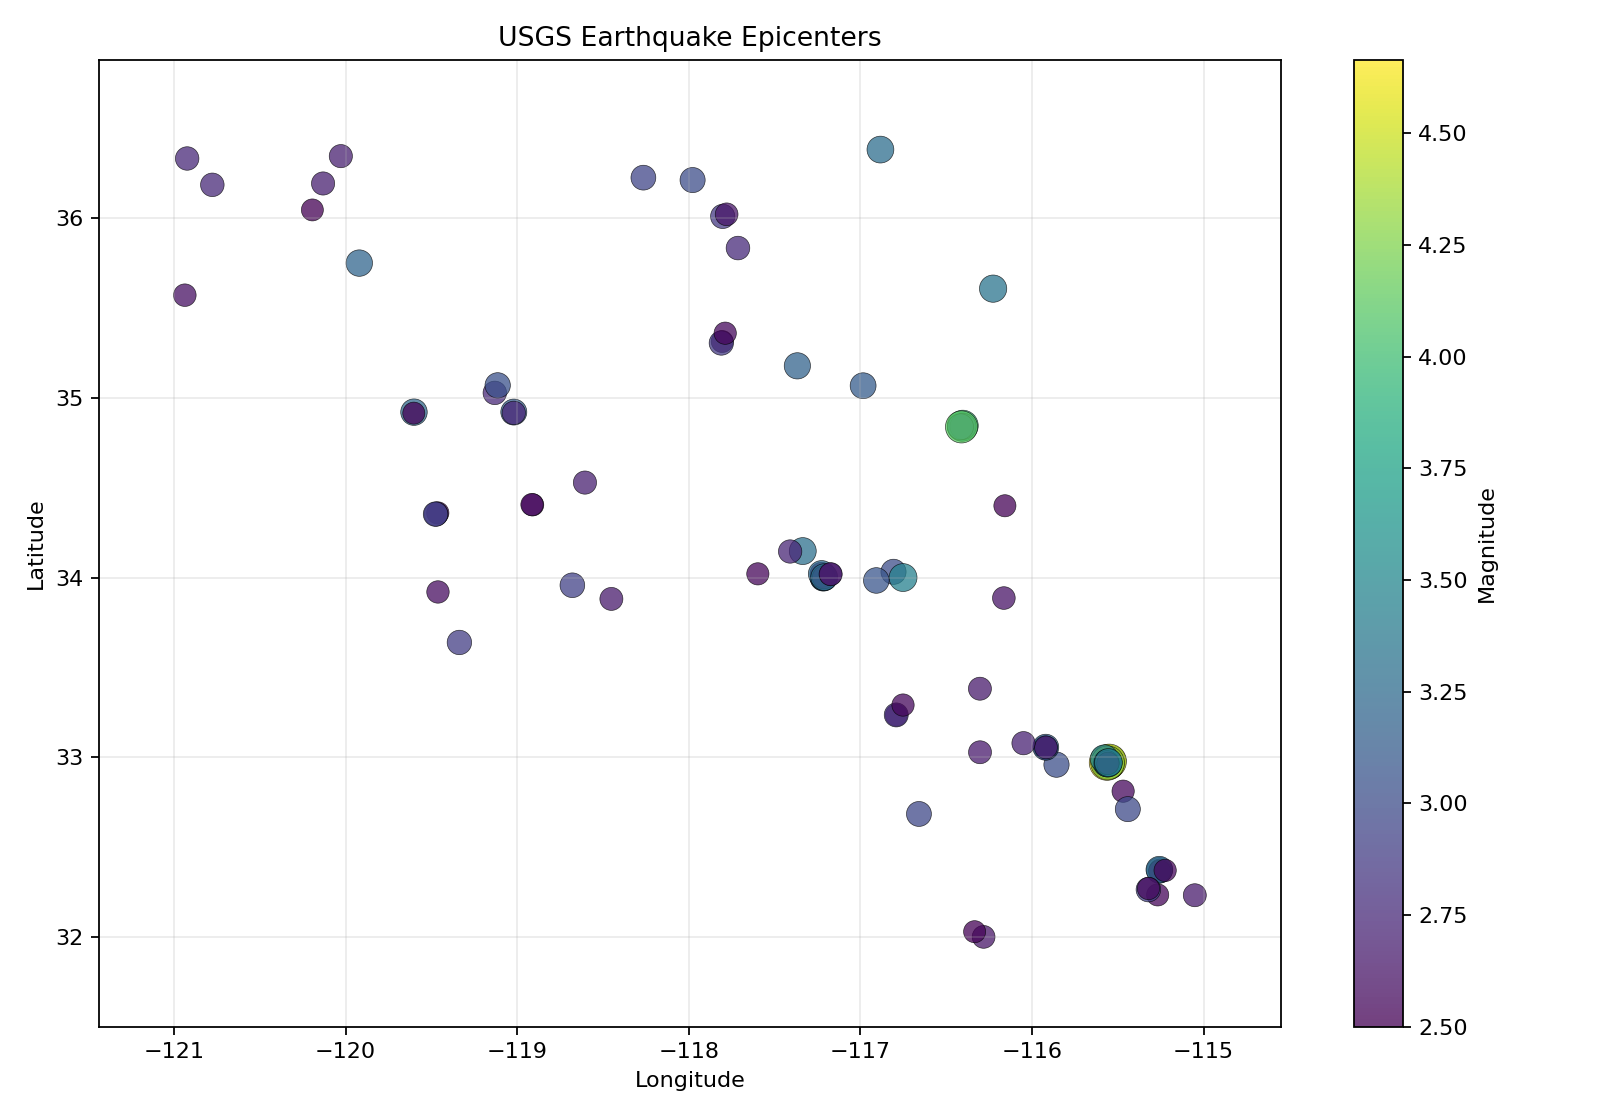

Artifact: usgs_earthquake_agent-8297-vuiq-2022.html


d:\GAS\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


Artifact: usgs_earthquake_agent-2400-kwvk-5402.geojson


,event_id,time,updated,place,mag,depth_km,longitude,latitude,sig,felt,...,type,status,url,detail,net,code,times,style_radius,style_color,geometry
0,ci41474768,2026-05-26 03:11:58.350000+00:00,1779826431140,"8 km S of Malibu Beach, CA",2.93,13.38,-118.678167,33.957667,172,137.0,...,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,ci,41474768,2026-05-26 03:11:58.350000+00:00,9.86,#d7191c,POINT (-118.67817 33.95767)
1,nc75368997,2026-05-26 02:13:32.080000+00:00,1779766342995,"7 km NW of Avenal, CA",2.50,9.00,-120.193169,36.046001,96,NaN,...,earthquake,automatic,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,nc,75368997,2026-05-26 02:13:32.080000+00:00,9.00,#d7191c,POINT (-120.19317 36.046)
2,ci41474616,2026-05-25 20:36:07.890000+00:00,1779819345380,"17 km WSW of Johannesburg, CA",2.50,7.15,-117.805000,35.313833,96,NaN,...,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,ci,41474616,2026-05-25 20:36:07.890000+00:00,9.00,#d7191c,POINT (-117.805 35.31383)
3,ci41474600,2026-05-25 20:23:15.140000+00:00,1779817889890,"13 km SSE of Santa Cruz Is. (E end), CA",2.57,9.90,-119.461333,33.920333,102,1.0,...,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,ci,41474600,2026-05-25 20:23:15.140000+00:00,9.14,#d7191c,POINT (-119.46133 33.92033)
4,ci41473864,2026-05-24 17:24:27.570000+00:00,1779816729170,"6 km WNW of Delta, B.C., MX",3.11,11.32,-115.257333,32.372000,149,NaN,...,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,ci,41473864,2026-05-24 17:24:27.570000+00:00,10.22,#d7191c,POINT (-115.25733 32.372)
5,nc75367877,2026-05-24 02:26:36.320000+00:00,1779640799050,"23 km NE of King City, CA",2.74,6.27,-120.922836,36.332165,116,1.0,...,earthquake,automatic,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,nc,75367877,2026-05-24 02:26:36.320000+00:00,9.48,#d7191c,POINT (-120.92284 36.33216)
6,ci41472912,2026-05-23 07:46:43.410000+00:00,1779817704991,"6 km WNW of Delta, B.C., MX",2.61,6.54,-115.253000,32.371000,105,1.0,...,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,ci,41472912,2026-05-23 07:46:43.410000+00:00,9.22,#d7191c,POINT (-115.253 32.371)
7,ci41472752,2026-05-23 01:09:37.190000+00:00,1779817273207,"21 km ESE of Little Lake, CA",2.76,6.42,-117.713167,35.833833,117,NaN,...,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,ci,41472752,2026-05-23 01:09:37.190000+00:00,9.52,#d7191c,POINT (-117.71317 35.83383)


[WindowsPath('d:/GAS/examples_for_using_gas_services/downloaded_gas_artifacts/usgs_earthquake_agent/usgs_earthquake_agent-6667-bopf-4119.geojson'),
 WindowsPath('d:/GAS/examples_for_using_gas_services/downloaded_gas_artifacts/usgs_earthquake_agent/usgs_earthquake_agent-1110-ddqi-7248.png'),
 WindowsPath('d:/GAS/examples_for_using_gas_services/downloaded_gas_artifacts/usgs_earthquake_agent/usgs_earthquake_agent-8297-vuiq-2022.html'),
 WindowsPath('d:/GAS/examples_for_using_gas_services/downloaded_gas_artifacts/usgs_earthquake_agent/usgs_earthquake_agent-2400-kwvk-5402.geojson')]

In [7]:
map_result = run_streaming_task(
    "Map M2.5+ earthquakes in Southern California during the past 90 days. Create a depth-colored map with a basemap and time-animation-ready GeoJSON.",
    parameters={"output_format": "geojson"},
)

display_task_artifacts(map_result, only_suffixes={".html", ".png", ".geojson", ".md"})

## 3. Summarize Earthquake Activity

This demonstrates `summarize_earthquake_activity`: the agent computes event counts, top events, magnitude/depth summaries, and a grid summary layer.

In [8]:
summary_result = run_streaming_task(
    "Summarize M3+ earthquake activity in Alaska during the past 180 days. Include top events, magnitude and depth summaries, and a grid summary layer.",
    parameters={"output_format": "geojson", "grid_degrees": 2.0},
)

show_earthquake_summary(summary_result)
display_task_artifacts(summary_result, only_suffixes={".geojson", ".csv", ".md"})

[00:45:27] stream_connected: Streaming connection established.
[00:45:27] USGS Earthquake Agent: I received your request.
[00:45:27] USGS Earthquake Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 0 dataset reference(s).
[00:45:27] USGS Earthquake Agent: I found the required credentials and can start the model-backed workflow.
[00:45:27] task_accepted: Task accepted. Starting streaming execution.
[00:45:28] USGS Earthquake Agent: Next I will run the agent with the prepared inputs.
[00:45:28] USGS Earthquake Agent: I am interpreting the earthquake request and choosing USGS query and output tools.
[00:45:33] USGS Earthquake Agent: I am retrieving earthquake events from USGS.
[00:45:34] USGS Earthquake Agent: USGS returned 1504 earthquake event(s).
[00:45:35] USGS Earthquake Agent: I am packaging earthquake datasets, maps, reports, provenance, and limitations.
[00:45:35] USGS Earthquake Agent: The agent finished its workflow,

{'type': 'earthquake_events',
 'dimensions': [1504, 19],
 'feature_count': 1504,
 'artifact_count': 3,
 'artifact_types': ['table', 'vector'],
 'formats': ['csv', 'geojson'],
 'crs': ['EPSG:4326', 'urn:ogc:def:crs:OGC:1.3:CRS84'],
 'combined_bbox': [-180.0, 50.0, -130.0, 70.0],
 'has_vector': True,
 'has_raster': False,
 'has_table': True,
 'feature_count_total': 3091,
 'has_spatial_metadata': True}

Artifact count: 3
- usgs_earthquake_agent-8614-aklx-0308.geojson geojson http://127.0.0.1:4042/agents/usgs_earthquake_agent/data/usgs_earthquake_agent-8614-aklx-0308.geojson
- usgs_earthquake_agent-2073-aiia-4323.csv csv http://127.0.0.1:4042/agents/usgs_earthquake_agent/data/usgs_earthquake_agent-2073-aiia-4323.csv
- usgs_earthquake_agent-1359-hpcf-2236.geojson geojson http://127.0.0.1:4042/agents/usgs_earthquake_agent/data/usgs_earthquake_agent-1359-hpcf-2236.geojson
Artifact: usgs_earthquake_agent-8614-aklx-0308.geojson


,event_id,time,updated,place,mag,depth_km,longitude,latitude,sig,felt,alert,tsunami,type,status,url,detail,net,code,geometry
0,us7000snqj,2026-05-26 21:56:36.730000+00:00,1779847311040,"162 km WSW of Adak, Alaska",3.0,83.389,-178.9338,51.5567,138,NaN,NaN,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,us,7000snqj,POINT (-178.9338 51.5567)
1,aka2026kjhudo,2026-05-26 19:17:37.304000+00:00,1779833900677,"114 km ESE of Akutan, Alaska",3.1,16.200,-164.1320,53.7770,148,NaN,NaN,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,ak,a2026kjhudo,POINT (-164.132 53.777)
2,aka2026kjcimz,2026-05-26 16:34:16.470000+00:00,1779833828903,"63 km NW of Tatitlek, Alaska",3.1,7.700,-147.5820,61.2340,148,1.0,NaN,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,ak,a2026kjcimz,POINT (-147.582 61.234)
3,us7000snlz,2026-05-26 15:46:03.460000+00:00,1779833740823,"84 km SSW of Sand Point, Alaska",3.7,18.643,-161.0689,54.6466,211,NaN,NaN,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,us,7000snlz,POINT (-161.0689 54.6466)
4,aka2026kiwqwe,2026-05-26 13:43:57.793000+00:00,1779819797149,"31 km SSW of Manley Hot Springs, Alaska",3.5,0.700,-150.8120,64.7280,188,NaN,NaN,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,ak,a2026kiwqwe,POINT (-150.812 64.728)
5,aka2026kibljn,2026-05-26 03:07:56.831000+00:00,1779771363716,"58 km SSW of Unalaska, Alaska",3.8,0.300,-166.9880,53.4190,222,NaN,NaN,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,ak,a2026kibljn,POINT (-166.988 53.419)
6,aka2026kiblgw,2026-05-26 03:07:49.766000+00:00,1779771487601,"59 km SSW of Unalaska, Alaska",3.0,2.800,-166.9960,53.4120,138,NaN,NaN,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,ak,a2026kiblgw,POINT (-166.996 53.412)
7,aka2026kibhpc,2026-05-26 03:03:34.180000+00:00,1779770656364,"60 km SSW of Unalaska, Alaska",3.6,2.000,-166.9840,53.3970,199,NaN,NaN,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,ak,a2026kibhpc,POINT (-166.984 53.397)


Artifact: usgs_earthquake_agent-2073-aiia-4323.csv


,event_id,time,place,mag,depth_km,latitude,longitude,sig,felt,alert,tsunami,url
0,us7000snqj,2026-05-26T21:56:36.730000+00:00,"162 km WSW of Adak, Alaska",3.0,83.389,51.5567,-178.9338,138,NaN,NaN,0,https://earthquake.usgs.gov/earthquakes/eventp...
1,aka2026kjhudo,2026-05-26T19:17:37.304000+00:00,"114 km ESE of Akutan, Alaska",3.1,16.200,53.7770,-164.1320,148,NaN,NaN,0,https://earthquake.usgs.gov/earthquakes/eventp...
2,aka2026kjcimz,2026-05-26T16:34:16.470000+00:00,"63 km NW of Tatitlek, Alaska",3.1,7.700,61.2340,-147.5820,148,1.0,NaN,0,https://earthquake.usgs.gov/earthquakes/eventp...
3,us7000snlz,2026-05-26T15:46:03.460000+00:00,"84 km SSW of Sand Point, Alaska",3.7,18.643,54.6466,-161.0689,211,NaN,NaN,0,https://earthquake.usgs.gov/earthquakes/eventp...
4,aka2026kiwqwe,2026-05-26T13:43:57.793000+00:00,"31 km SSW of Manley Hot Springs, Alaska",3.5,0.700,64.7280,-150.8120,188,NaN,NaN,0,https://earthquake.usgs.gov/earthquakes/eventp...
5,aka2026kibljn,2026-05-26T03:07:56.831000+00:00,"58 km SSW of Unalaska, Alaska",3.8,0.300,53.4190,-166.9880,222,NaN,NaN,0,https://earthquake.usgs.gov/earthquakes/eventp...
6,aka2026kiblgw,2026-05-26T03:07:49.766000+00:00,"59 km SSW of Unalaska, Alaska",3.0,2.800,53.4120,-166.9960,138,NaN,NaN,0,https://earthquake.usgs.gov/earthquakes/eventp...
7,aka2026kibhpc,2026-05-26T03:03:34.180000+00:00,"60 km SSW of Unalaska, Alaska",3.6,2.000,53.3970,-166.9840,199,NaN,NaN,0,https://earthquake.usgs.gov/earthquakes/eventp...


Artifact: usgs_earthquake_agent-1359-hpcf-2236.geojson


,grid_id,event_count,max_magnitude,mean_depth_km,geometry
0,-180.0_50.0,46,5.0,40.856913,"POLYGON ((-178 50, -178 52, -180 52, -180 50, ..."
1,-178.0_50.0,64,5.3,44.109563,"POLYGON ((-176 50, -176 52, -178 52, -178 50, ..."
2,-176.0_50.0,47,5.0,38.357553,"POLYGON ((-174 50, -174 52, -176 52, -176 50, ..."
3,-174.0_50.0,22,5.1,29.897955,"POLYGON ((-172 50, -172 52, -174 52, -174 50, ..."
4,-172.0_50.0,11,5.3,18.013273,"POLYGON ((-170 50, -170 52, -172 52, -172 50, ..."
5,-170.0_50.0,20,4.7,11.685100,"POLYGON ((-168 50, -168 52, -170 52, -170 50, ..."
6,-168.0_50.0,2,3.8,10.000000,"POLYGON ((-166 50, -166 52, -168 52, -168 50, ..."
7,-180.0_52.0,1,4.7,127.422000,"POLYGON ((-178 52, -178 54, -180 54, -180 52, ..."


[WindowsPath('d:/GAS/examples_for_using_gas_services/downloaded_gas_artifacts/usgs_earthquake_agent/usgs_earthquake_agent-8614-aklx-0308.geojson'),
 WindowsPath('d:/GAS/examples_for_using_gas_services/downloaded_gas_artifacts/usgs_earthquake_agent/usgs_earthquake_agent-2073-aiia-4323.csv'),
 WindowsPath('d:/GAS/examples_for_using_gas_services/downloaded_gas_artifacts/usgs_earthquake_agent/usgs_earthquake_agent-1359-hpcf-2236.geojson')]

## 4. Analyze Earthquake Patterns

This demonstrates `analyze_earthquake_patterns`: the agent creates impact buffers and performs simple cluster screening. These are screening artifacts for geospatial workflows, not formal seismic hazard products.

In [9]:
pattern_result = run_streaming_task(
    "Analyze M2.5+ earthquake patterns in California during the past 300 days. Create impact buffers and screen for clusters.",
    parameters={"output_format": "geojson", "buffer_km": 50},
)

display_task_artifacts(pattern_result, only_suffixes={".geojson", ".png", ".md"})

[00:46:53] stream_connected: Streaming connection established.
[00:46:53] USGS Earthquake Agent: I received your request.
[00:46:53] USGS Earthquake Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 0 dataset reference(s).
[00:46:53] USGS Earthquake Agent: I found the required credentials and can start the model-backed workflow.
[00:46:53] task_accepted: Task accepted. Starting streaming execution.
[00:46:53] USGS Earthquake Agent: Next I will run the agent with the prepared inputs.
[00:46:54] USGS Earthquake Agent: I am interpreting the earthquake request and choosing USGS query and output tools.
[00:46:56] USGS Earthquake Agent: I am retrieving earthquake events from USGS.
[00:46:58] USGS Earthquake Agent: USGS returned 1167 earthquake event(s).
[00:46:58] USGS Earthquake Agent: I am packaging earthquake datasets, maps, reports, provenance, and limitations.
[00:46:58] USGS Earthquake Agent: The agent finished its workflow,

,event_id,time,updated,place,mag,depth_km,longitude,latitude,sig,felt,alert,tsunami,type,status,url,detail,net,code,geometry
0,nc75369102,2026-05-26 07:12:03.610000+00:00,1779796475089,"26 km NE of Viola, CA",2.68,8.30,-121.448502,40.674500,111,1.0,NaN,0,earthquake,automatic,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,nc,75369102,POINT (-121.4485 40.6745)
1,nc75369057,2026-05-26 05:11:52.440000+00:00,1779817081856,"26 km NE of Viola, CA",3.42,7.05,-121.447500,40.675667,183,9.0,NaN,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,nc,75369057,POINT (-121.4475 40.67567)
2,ci41474768,2026-05-26 03:11:58.350000+00:00,1779826431140,"8 km S of Malibu Beach, CA",2.93,13.38,-118.678167,33.957667,172,137.0,NaN,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,ci,41474768,POINT (-118.67817 33.95767)
3,nc75368997,2026-05-26 02:13:32.080000+00:00,1779766342995,"7 km NW of Avenal, CA",2.50,9.00,-120.193169,36.046001,96,NaN,NaN,0,earthquake,automatic,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,nc,75368997,POINT (-120.19317 36.046)
4,ci41474616,2026-05-25 20:36:07.890000+00:00,1779819345380,"17 km WSW of Johannesburg, CA",2.50,7.15,-117.805000,35.313833,96,NaN,NaN,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,ci,41474616,POINT (-117.805 35.31383)
5,ci41474600,2026-05-25 20:23:15.140000+00:00,1779817889890,"13 km SSE of Santa Cruz Is. (E end), CA",2.57,9.90,-119.461333,33.920333,102,1.0,NaN,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,ci,41474600,POINT (-119.46133 33.92033)
6,nn00919169,2026-05-25 08:52:42.839000+00:00,1779804903182,"34 km SE of Mina, Nevada",3.75,7.00,-117.849800,38.157300,217,2.0,NaN,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,nn,00919169,POINT (-117.8498 38.1573)
7,ci41473864,2026-05-24 17:24:27.570000+00:00,1779816729170,"6 km WNW of Delta, B.C., MX",3.11,11.32,-115.257333,32.372000,149,NaN,NaN,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,ci,41473864,POINT (-115.25733 32.372)


Artifact: usgs_earthquake_agent-0517-qhoc-1906.geojson


,event_id,mag,buffer_km,geometry
0,nc75369102,2.68,67.00,"POLYGON ((-120.84663 40.6745, -120.84953 40.62..."
1,nc75369057,3.42,85.50,"POLYGON ((-120.67944 40.67567, -120.68314 40.6..."
2,ci41474768,2.93,73.25,"POLYGON ((-118.02015 33.95767, -118.02332 33.9..."
3,nc75368997,2.50,62.50,"POLYGON ((-119.63172 36.046, -119.63443 36.001..."
4,ci41474616,2.50,62.50,"POLYGON ((-117.24355 35.31383, -117.24626 35.2..."
5,ci41474600,2.57,64.25,"POLYGON ((-118.88417 33.92033, -118.88694 33.8..."
6,nn00919169,3.75,93.75,"POLYGON ((-117.00763 38.1573, -117.01168 38.09..."
7,ci41473864,3.11,77.75,"POLYGON ((-114.55889 32.372, -114.56226 32.314..."


[WindowsPath('d:/GAS/examples_for_using_gas_services/downloaded_gas_artifacts/usgs_earthquake_agent/usgs_earthquake_agent-0753-zdek-2442.geojson'),
 WindowsPath('d:/GAS/examples_for_using_gas_services/downloaded_gas_artifacts/usgs_earthquake_agent/usgs_earthquake_agent-0517-qhoc-1906.geojson')]

## 5. Generate Alert-Ready Summary

This demonstrates `generate_alert_ready_summary`: the agent uses a real-time USGS feed or thresholded catalog query and produces concise monitoring text.

In [16]:
alert_result = run_streaming_task(
    "Run a latest significant earthquake check and produce an alert-ready summary for the past 30 day.",
    parameters={"feed_period": "day", "feed_magnitude": "significant", "output_format": "geojson"},
)

alert_summary = alert_result.get("outputs", {}).get("summary")
display(Markdown(f"### Alert-ready summary\n\n{alert_summary}"))
display_task_artifacts(alert_result, only_suffixes={".geojson", ".csv", ".md"})

[00:49:35] stream_connected: Streaming connection established.
[00:49:35] USGS Earthquake Agent: I received your request.
[00:49:35] USGS Earthquake Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 0 dataset reference(s).
[00:49:35] USGS Earthquake Agent: I found the required credentials and can start the model-backed workflow.
[00:49:36] task_accepted: Task accepted. Starting streaming execution.
[00:49:36] USGS Earthquake Agent: Next I will run the agent with the prepared inputs.
[00:49:36] USGS Earthquake Agent: I am interpreting the earthquake request and choosing USGS query and output tools.
[00:49:38] USGS Earthquake Agent: I am retrieving earthquake events from USGS.
[00:49:38] USGS Earthquake Agent: USGS returned 8 earthquake event(s).
[00:49:38] USGS Earthquake Agent: I am packaging earthquake datasets, maps, reports, provenance, and limitations.
[00:49:38] USGS Earthquake Agent: The agent finished its workflow, so

### Alert-ready summary

Retrieved 8 USGS earthquake event(s). Primary dataset saved as earthquakes_run_a_latest_significant_701623.geojson. 8 M4.5+ earthquake event(s) were found for the requested area. The largest event was M6.9 near 29 km ENE of Calama, Chile at 2026-05-25T21:52:20.043000+00:00.

Artifact: usgs_earthquake_agent-2521-phax-9832.geojson


,event_id,time,updated,place,mag,depth_km,longitude,latitude,sig,felt,alert,tsunami,type,status,url,detail,net,code,geometry
0,us6000t04s,2026-05-25 21:52:20.043000+00:00,1779840939693,"29 km ENE of Calama, Chile",6.900000,109.000,-68.642200,-22.388300,777,75.0,green,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/earthquakes/feed/v...,us,6000t04s,POINT (-68.6422 -22.3883)
1,hv74966427,2026-05-23 07:46:01.480000+00:00,1779854339124,"13 km S of Honaunau-Napoopoo, Hawaii",5.960000,22.640,-155.842500,19.340333,1380,7181.0,yellow,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/earthquakes/feed/v...,hv,74966427,POINT (-155.8425 19.34033)
2,us6000sz1d,2026-05-20 17:43:01.910000+00:00,1779387145066,southern East Pacific Rise,6.600000,10.000,-122.298800,-55.984000,670,NaN,green,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/earthquakes/feed/v...,us,6000sz1d,POINT (-122.2988 -55.984)
3,us6000syik,2026-05-18 13:44:26.120000+00:00,1779822410040,"24 km NW of Liuzhou, China",5.100000,10.000,109.266600,24.499200,1006,12.0,orange,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/earthquakes/feed/v...,us,6000syik,POINT (109.2666 24.4992)
4,us6000sy84,2026-05-16 14:50:05.948000+00:00,1779229140703,"60 km ESE of Codrington, Antigua and Barbuda",6.000000,51.245,-61.293800,17.429500,615,122.0,green,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/earthquakes/feed/v...,us,6000sy84,POINT (-61.2938 17.4295)
5,us6000sxwq,2026-05-15 11:22:01.649000+00:00,1779061975821,"49 km ESE of Ōfunato, Japan",6.700000,43.592,142.249800,38.912700,752,93.0,green,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/earthquakes/feed/v...,us,6000sxwq,POINT (142.2498 38.9127)
6,ci41461608,2026-05-10 07:10:21.250000+00:00,1779780036718,"3 km WSW of Brawley, CA",4.664869,14.530,-115.562333,32.971333,600,203.0,green,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/earthquakes/feed/v...,ci,41461608,POINT (-115.56233 32.97133)
7,nn00916980,2026-05-01 08:17:19.870000+00:00,1778404951986,"19 km SE of Silver Springs, Nevada",5.170000,5.000,-119.046700,39.306600,961,1871.0,green,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/earthquakes/feed/v...,nn,00916980,POINT (-119.0467 39.3066)


Artifact: usgs_earthquake_agent-2039-slxe-1776.csv


,event_id,time,place,mag,depth_km,latitude,longitude,sig,felt,alert,tsunami,url
0,us6000t04s,2026-05-25T21:52:20.043000+00:00,"29 km ENE of Calama, Chile",6.900000,109.000,-22.388300,-68.642200,777,75.0,green,0,https://earthquake.usgs.gov/earthquakes/eventp...
1,hv74966427,2026-05-23T07:46:01.480000+00:00,"13 km S of Honaunau-Napoopoo, Hawaii",5.960000,22.640,19.340333,-155.842500,1380,7181.0,yellow,0,https://earthquake.usgs.gov/earthquakes/eventp...
2,us6000sz1d,2026-05-20T17:43:01.910000+00:00,southern East Pacific Rise,6.600000,10.000,-55.984000,-122.298800,670,NaN,green,0,https://earthquake.usgs.gov/earthquakes/eventp...
3,us6000syik,2026-05-18T13:44:26.120000+00:00,"24 km NW of Liuzhou, China",5.100000,10.000,24.499200,109.266600,1006,12.0,orange,0,https://earthquake.usgs.gov/earthquakes/eventp...
4,us6000sy84,2026-05-16T14:50:05.948000+00:00,"60 km ESE of Codrington, Antigua and Barbuda",6.000000,51.245,17.429500,-61.293800,615,122.0,green,0,https://earthquake.usgs.gov/earthquakes/eventp...
5,us6000sxwq,2026-05-15T11:22:01.649000+00:00,"49 km ESE of Ōfunato, Japan",6.700000,43.592,38.912700,142.249800,752,93.0,green,0,https://earthquake.usgs.gov/earthquakes/eventp...
6,ci41461608,2026-05-10T07:10:21.250000+00:00,"3 km WSW of Brawley, CA",4.664869,14.530,32.971333,-115.562333,600,203.0,green,0,https://earthquake.usgs.gov/earthquakes/eventp...
7,nn00916980,2026-05-01T08:17:19.870000+00:00,"19 km SE of Silver Springs, Nevada",5.170000,5.000,39.306600,-119.046700,961,1871.0,green,0,https://earthquake.usgs.gov/earthquakes/eventp...


Artifact: usgs_earthquake_agent-5185-sxjk-7813.md


# USGS Earthquake Activity Report

Task: Run a latest significant earthquake check and produce an alert-ready summary for the past 30 day.
Retrieved at: 2026-05-27T04:49:38.958075+00:00

## Summary

- Event count: 8
- Maximum magnitude: 6.9
- Mean depth km: 33.25087499999999

## Alert Summary

8 M4.5+ earthquake event(s) were found for the requested area. The largest event was M6.9 near 29 km ENE of Calama, Chile at 2026-05-25T21:52:20.043000+00:00.

## Top Events

| Time | Place | Magnitude | Depth km | Alert | URL |
|---|---|---:|---:|---|---|
| 2026-05-25T21:52:20.043000+00:00 | 29 km ENE of Calama, Chile | 6.9 | 109.0 | green | https://earthquake.usgs.gov/earthquakes/eventpage/us6000t04s |
| 2026-05-15T11:22:01.649000+00:00 | 49 km ESE of Ōfunato, Japan | 6.7 | 43.592 | green | https://earthquake.usgs.gov/earthquakes/eventpage/us6000sxwq |
| 2026-05-20T17:43:01.910000+00:00 | southern East Pacific Rise | 6.6 | 10.0 | green | https://earthquake.usgs.gov/earthquakes/eventpage/us6000sz1d |
| 2026-05-16T14:50:05.948000+00:00 | 60 km ESE of Codrington, Antigua and Barbuda | 6.0 | 51.245 | green | https://earthquake.usgs.gov/earthquakes/eventpage/us6000sy84 |
| 2026-05-23T07:46:01.480000+00:00 | 13 km S of Honaunau-Napoopoo, Hawaii | 5.96 | 22.64 | yellow | https://earthquake.usgs.gov/earthquakes/eventpage/hv74966427 |
| 2026-05-01T08:17:19.870000+00:00 | 19 km SE of Silver Springs, Nevada | 5.17 | 5.0 | green | https://earthquake.usgs.gov/earthquakes/eventpage/nn00916980 |
| 2026-05-18T13:44:26.120000+00:00 | 24 km NW of Liuzhou, China | 5.1 | 10.0 | orange | https://earthquake.usgs.gov/earthquakes/eventpage/us6000syik |
| 2026-05-10T07:10:21.250000+00:00 | 3 km WSW of Brawley, CA | 4.66486919122063 | 14.53 | green | https://earthquake.usgs.gov/earthquakes/eventpage/ci41461608 |

## Methods And Provenance

- USGS endpoint: https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/significant_month.geojson
- Query parameters: `{"feed_magnitude": "significant", "feed_period": "month"}`

## Limitations

- Recent USGS event records can be revised after initial publication.
- Magnitudes, depths, and locations may change as reviews are completed.
- Very recent or low-magnitude catalogs may be incomplete depending on network coverage.

[WindowsPath('d:/GAS/examples_for_using_gas_services/downloaded_gas_artifacts/usgs_earthquake_agent/usgs_earthquake_agent-2521-phax-9832.geojson'),
 WindowsPath('d:/GAS/examples_for_using_gas_services/downloaded_gas_artifacts/usgs_earthquake_agent/usgs_earthquake_agent-2039-slxe-1776.csv'),
 WindowsPath('d:/GAS/examples_for_using_gas_services/downloaded_gas_artifacts/usgs_earthquake_agent/usgs_earthquake_agent-5185-sxjk-7813.md')]

## 6. Generate Earthquake Report

This demonstrates `generate_earthquake_report`: the agent returns Markdown and HTML reports with maps, charts, event tables, methods/provenance, and limitations.

[00:49:03] stream_connected: Streaming connection established.
[00:49:03] USGS Earthquake Agent: I received your request.
[00:49:03] USGS Earthquake Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 0 dataset reference(s).
[00:49:03] USGS Earthquake Agent: I found the required credentials and can start the model-backed workflow.
[00:49:03] task_accepted: Task accepted. Starting streaming execution.
[00:49:04] USGS Earthquake Agent: Next I will run the agent with the prepared inputs.
[00:49:04] USGS Earthquake Agent: I am interpreting the earthquake request and choosing USGS query and output tools.
[00:49:06] USGS Earthquake Agent: I am retrieving earthquake events from USGS.
[00:49:08] USGS Earthquake Agent: USGS returned 461 earthquake event(s).
[00:49:09] USGS Earthquake Agent: I am packaging earthquake datasets, maps, reports, provenance, and limitations.
[00:49:09] USGS Earthquake Agent: The agent finished its workflow, 

,event_id,time,place,mag,depth_km,latitude,longitude,sig,felt,alert,tsunami,url
0,us7000snpq,2026-05-26T20:21:01.985000+00:00,"31 km SE of Ōfunato, Japan",4.5,62.215,38.8774,141.9779,312,NaN,NaN,0,https://earthquake.usgs.gov/earthquakes/eventp...
1,us6000t00y,2026-05-25T08:14:48.144000+00:00,"50 km ENE of Noda, Japan",4.8,49.176,40.2438,142.3871,354,NaN,NaN,0,https://earthquake.usgs.gov/earthquakes/eventp...
2,us6000szw2,2026-05-24T06:51:36.264000+00:00,"64 km E of Nemuro, Japan",4.5,74.540,43.2687,146.3643,312,NaN,NaN,0,https://earthquake.usgs.gov/earthquakes/eventp...
3,us6000szjp,2026-05-22T16:53:58.546000+00:00,"40 km ENE of Kuji, Japan",4.6,61.454,40.3053,142.2201,326,NaN,NaN,0,https://earthquake.usgs.gov/earthquakes/eventp...
4,us6000syva,2026-05-19T23:11:56.183000+00:00,"25 km NW of Takayama, Japan",4.5,262.065,36.3152,137.0770,312,NaN,NaN,0,https://earthquake.usgs.gov/earthquakes/eventp...
5,us6000syq4,2026-05-19T10:23:35.881000+00:00,"91 km ENE of Hachinohe, Japan",4.5,70.490,40.8830,142.4521,312,NaN,NaN,0,https://earthquake.usgs.gov/earthquakes/eventp...
6,us6000syk9,2026-05-18T17:04:31.928000+00:00,"113 km E of Miyako, Japan",4.6,35.000,39.8010,143.2523,326,NaN,NaN,0,https://earthquake.usgs.gov/earthquakes/eventp...
7,us6000syak,2026-05-17T00:07:28.770000+00:00,"93 km ENE of Miyako, Japan",4.7,35.000,39.9621,142.9476,340,NaN,NaN,0,https://earthquake.usgs.gov/earthquakes/eventp...


Artifact: usgs_earthquake_agent-4454-gszg-0934.png


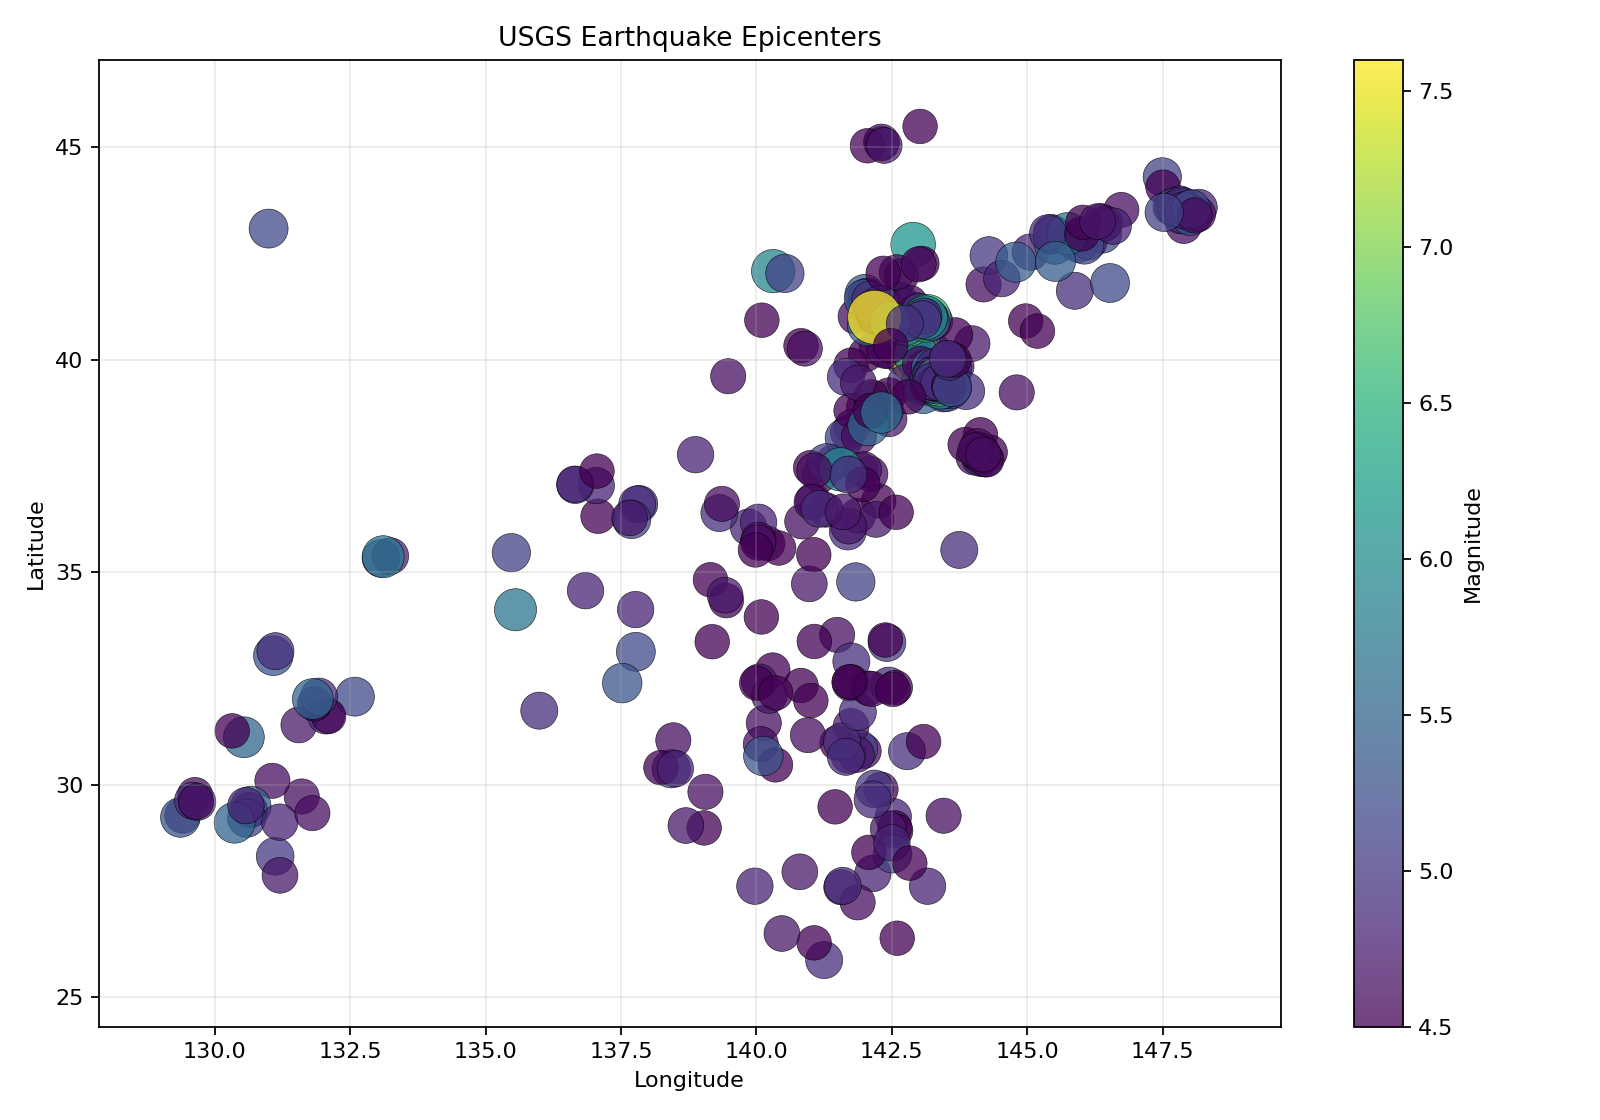

Artifact: usgs_earthquake_agent-1050-tgys-6326.html


d:\GAS\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


Artifact: usgs_earthquake_agent-9419-izzr-0516.png


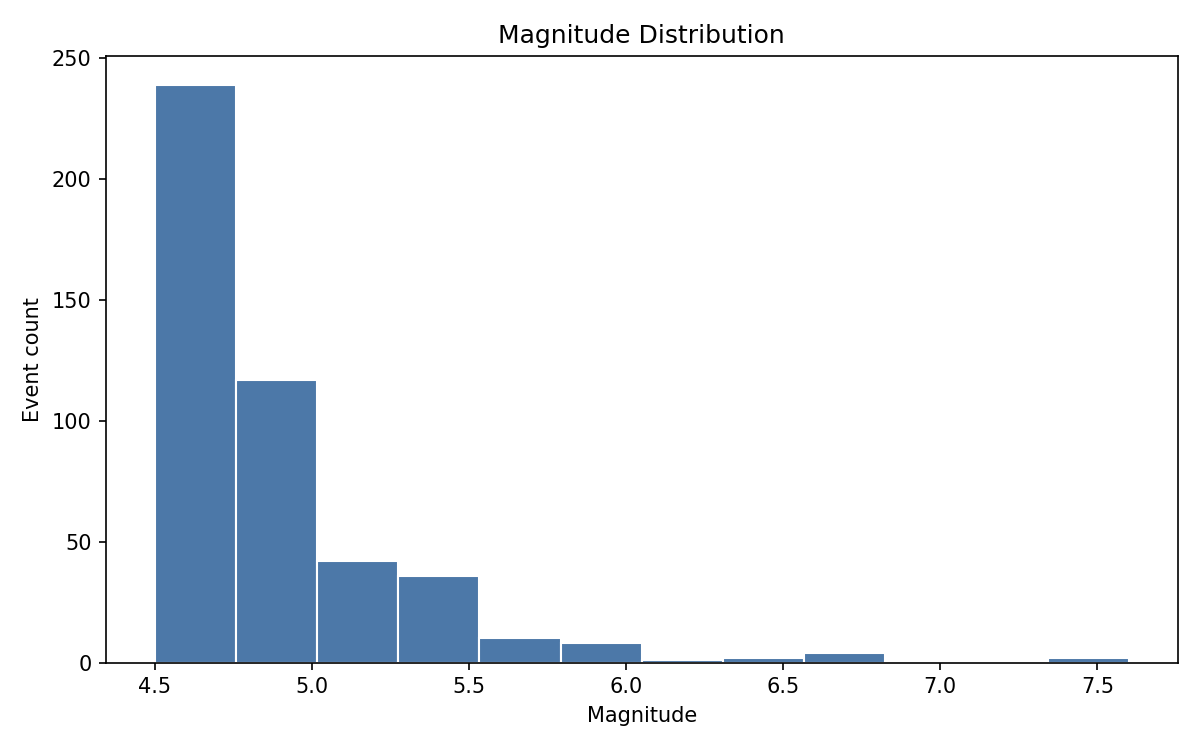

Artifact: usgs_earthquake_agent-5051-mvxx-8541.png


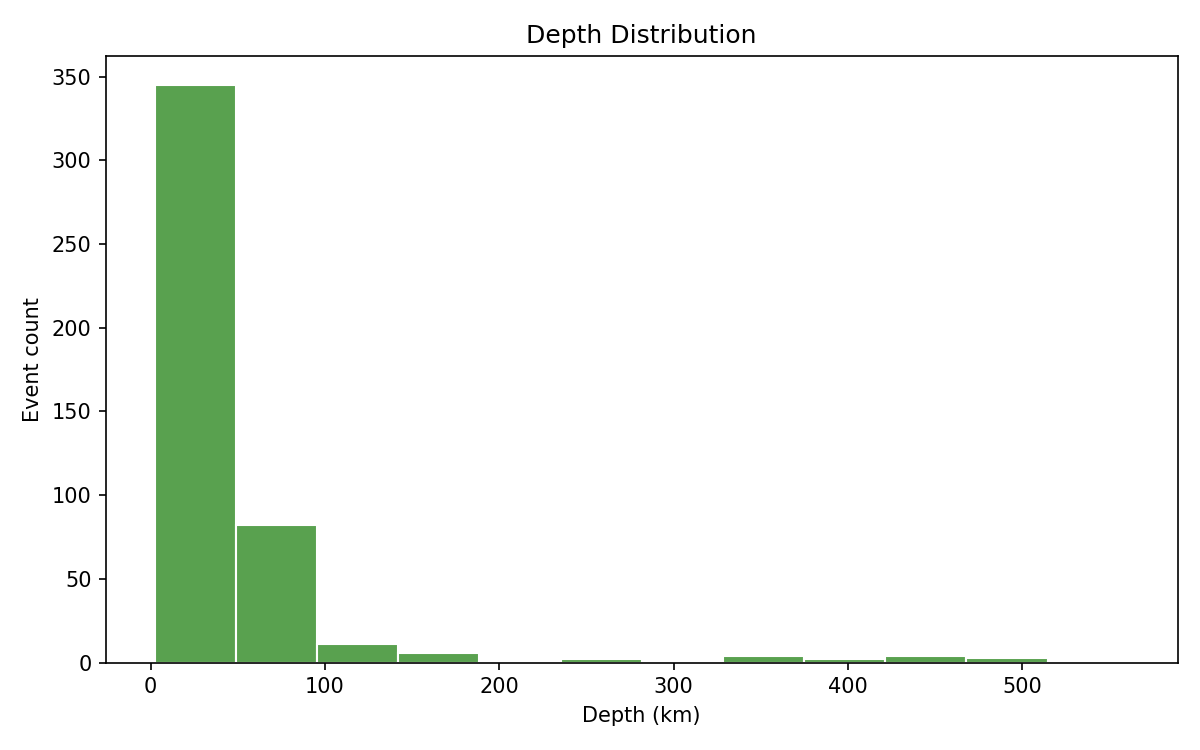

Artifact: usgs_earthquake_agent-0097-vqfa-2289.md


# USGS Earthquake Activity Report

Task: Generate an HTML earthquake activity report for M4.5+ earthquakes near Japan during the past 300 days. Include maps, charts, top events, methods, provenance, and limitations.
Retrieved at: 2026-05-27T04:49:09.113663+00:00

## Summary

- Event count: 461
- Maximum magnitude: 7.6
- Mean depth km: 46.867776572668106

## Top Events

| Time | Place | Magnitude | Depth km | Alert | URL |
|---|---|---:|---:|---|---|
| 2025-12-08T14:15:09.896000+00:00 | 2025 Aomori Prefecture, Japan Earthquake | 7.6 | 40.72 | yellow | https://earthquake.usgs.gov/earthquakes/eventpage/us6000rtdt |
| 2026-04-20T07:52:58.951000+00:00 | 98 km ENE of Miyako, Japan | 7.4 | 25.0 | green | https://earthquake.usgs.gov/earthquakes/eventpage/us6000sri7 |
| 2025-11-09T08:03:39.367000+00:00 | 122 km E of Yamada, Japan | 6.8 | 18.0 | green | https://earthquake.usgs.gov/earthquakes/eventpage/us6000rmea |
| 2026-05-15T11:22:01.649000+00:00 | 49 km ESE of Ōfunato, Japan | 6.7 | 43.592 | green | https://earthquake.usgs.gov/earthquakes/eventpage/us6000sxwq |
| 2025-12-12T02:44:12.841000+00:00 | 117 km NE of Kuji, Japan | 6.7 | 19.0 | green | https://earthquake.usgs.gov/earthquakes/eventpage/us6000ruc4 |
| 2025-12-08T21:52:41.325000+00:00 | 129 km S of Honchō, Japan | 6.6 | 19.0 | green | https://earthquake.usgs.gov/earthquakes/eventpage/us6000rtie |
| 2026-03-26T14:18:51.927000+00:00 | 123 km E of Yamada, Japan | 6.5 | 16.0 | green | https://earthquake.usgs.gov/earthquakes/eventpage/us7000s7u4 |
| 2025-11-09T08:54:36.914000+00:00 | 117 km E of Yamada, Japan | 6.4 | 10.0 | green | https://earthquake.usgs.gov/earthquakes/eventpage/us6000rmep |
| 2026-04-26T20:23:55.653000+00:00 | 24 km WNW of Sarabetsu, Japan | 6.1 | 81.0 | green | https://earthquake.usgs.gov/earthquakes/eventpage/us6000st1m |
| 2025-12-31T14:26:57.992000+00:00 | 96 km E of Noda, Japan | 6.0 | 27.0 | green | https://earthquake.usgs.gov/earthquakes/eventpage/us7000rlq3 |

## Methods And Provenance

- USGS endpoint: https://earthquake.usgs.gov/fdsnws/event/1/query
- Query parameters: `{"starttime": "now-300days", "endtime": "now", "minmagnitude": 4.5, "minlongitude": 122.0, "minlatitude": 24.0, "maxlongitude": 154.0, "maxlatitude": 46.5, "eventtype": "earthquake", "latitude": 36.2048, "longitude": 138.2529, "maxradiuskm": 1200, "format": "geojson", "orderby": "time"}`

## Limitations

- Recent USGS event records can be revised after initial publication.
- Magnitudes, depths, and locations may change as reviews are completed.
- Very recent or low-magnitude catalogs may be incomplete depending on network coverage.

Artifact: usgs_earthquake_agent-0395-dbjh-5131.html


Time,Place,Magnitude,Depth km,Alert,URL
2025-12-08T14:15:09.896000+00:00,"2025 Aomori Prefecture, Japan Earthquake",7.6,40.72,yellow,USGS
2026-04-20T07:52:58.951000+00:00,"98 km ENE of Miyako, Japan",7.4,25.0,green,USGS
2025-11-09T08:03:39.367000+00:00,"122 km E of Yamada, Japan",6.8,18.0,green,USGS
2026-05-15T11:22:01.649000+00:00,"49 km ESE of Ōfunato, Japan",6.7,43.592,green,USGS
2025-12-12T02:44:12.841000+00:00,"117 km NE of Kuji, Japan",6.7,19.0,green,USGS
2025-12-08T21:52:41.325000+00:00,"129 km S of Honchō, Japan",6.6,19.0,green,USGS
2026-03-26T14:18:51.927000+00:00,"123 km E of Yamada, Japan",6.5,16.0,green,USGS
2025-11-09T08:54:36.914000+00:00,"117 km E of Yamada, Japan",6.4,10.0,green,USGS
2026-04-26T20:23:55.653000+00:00,"24 km WNW of Sarabetsu, Japan",6.1,81.0,green,USGS
2025-12-31T14:26:57.992000+00:00,"96 km E of Noda, Japan",6.0,27.0,green,USGS


[WindowsPath('d:/GAS/examples_for_using_gas_services/downloaded_gas_artifacts/usgs_earthquake_agent/usgs_earthquake_agent-1850-fqna-3721.csv'),
 WindowsPath('d:/GAS/examples_for_using_gas_services/downloaded_gas_artifacts/usgs_earthquake_agent/usgs_earthquake_agent-4454-gszg-0934.png'),
 WindowsPath('d:/GAS/examples_for_using_gas_services/downloaded_gas_artifacts/usgs_earthquake_agent/usgs_earthquake_agent-1050-tgys-6326.html'),
 WindowsPath('d:/GAS/examples_for_using_gas_services/downloaded_gas_artifacts/usgs_earthquake_agent/usgs_earthquake_agent-9419-izzr-0516.png'),
 WindowsPath('d:/GAS/examples_for_using_gas_services/downloaded_gas_artifacts/usgs_earthquake_agent/usgs_earthquake_agent-5051-mvxx-8541.png'),
 WindowsPath('d:/GAS/examples_for_using_gas_services/downloaded_gas_artifacts/usgs_earthquake_agent/usgs_earthquake_agent-0097-vqfa-2289.md'),
 WindowsPath('d:/GAS/examples_for_using_gas_services/downloaded_gas_artifacts/usgs_earthquake_agent/usgs_earthquake_agent-0395-dbjh-5131

In [14]:
report_result = run_streaming_task(
    "Generate an HTML earthquake activity report for M4.5+ earthquakes near Japan during the past 300 days. Include maps, charts, top events, methods, provenance, and limitations.",
    parameters={"output_format": "geojson"},
)

display_task_artifacts(report_result, only_suffixes={".html", ".md", ".png", ".csv"})

## Artifact URLs

The returned URLs can be passed to other GAS agents, such as the Mapping Agent, Web Mapping App Agent, Spatial Statistics Agent, or Vector Analysis Agent.

In [17]:
all_results = {
    "retrieve_export": retrieve_export_result,
    "map": map_result,
    "summary": summary_result,
    "patterns": pattern_result,
    "alert": alert_result,
    "report": report_result,
}

for label, result in all_results.items():
    print(f"\n{label}")
    for artifact in result.get("outputs", {}).get("artifacts", []):
        print("-", artifact.get("format"), artifact.get("name"), absolute_url(artifact.get("url")))


retrieve_export
- csv usgs_earthquake_agent-6548-aolm-8118.csv http://127.0.0.1:4042/agents/usgs_earthquake_agent/data/usgs_earthquake_agent-6548-aolm-8118.csv

map
- geojson usgs_earthquake_agent-6667-bopf-4119.geojson http://127.0.0.1:4042/agents/usgs_earthquake_agent/data/usgs_earthquake_agent-6667-bopf-4119.geojson
- png usgs_earthquake_agent-1110-ddqi-7248.png http://127.0.0.1:4042/agents/usgs_earthquake_agent/data/usgs_earthquake_agent-1110-ddqi-7248.png
- html usgs_earthquake_agent-8297-vuiq-2022.html http://127.0.0.1:4042/agents/usgs_earthquake_agent/data/usgs_earthquake_agent-8297-vuiq-2022.html
- geojson usgs_earthquake_agent-2400-kwvk-5402.geojson http://127.0.0.1:4042/agents/usgs_earthquake_agent/data/usgs_earthquake_agent-2400-kwvk-5402.geojson

summary
- geojson usgs_earthquake_agent-8614-aklx-0308.geojson http://127.0.0.1:4042/agents/usgs_earthquake_agent/data/usgs_earthquake_agent-8614-aklx-0308.geojson
- csv usgs_earthquake_agent-2073-aiia-4323.csv http://127.0.0.1:40